In [691]:
# 1. 匯入必要的函式庫
import pandas as pd

In [692]:
# 2. 讀取 Excel 檔案
data = pd.read_excel('/Users/mikawu/Desktop/AP_provide20250304.xlsx')
data

,ID,Institute,Sex,Age,CCI,Cancer_site,Stage,Chemotherapy,Smoking,SMI,CE,Cricopharyngeus,EIM,GL,Inferior_PCM,Middle_PCM,Superior_PCM,SGL,AP
0,3,0,2,29,0,1,1,0,0,63.041176,43.225,43.874,46.622,40.667,36.672,40.283,41.586,42.036,0
1,4,0,2,55,1,3,1,1,0,53.412403,25.606,43.642,39.342,39.807,42.854,45.139,41.519,45.830,0
2,6,0,2,68,2,3,1,0,1,53.568044,41.741,48.503,40.566,45.774,39.636,45.419,52.312,46.020,0
3,8,0,2,39,0,2,1,1,0,61.041882,31.175,44.014,43.342,43.899,38.321,42.328,49.486,46.302,0
4,11,0,2,55,1,3,1,1,0,53.456790,32.858,44.199,44.066,43.492,43.392,53.522,60.657,45.889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,100713,1,2,64,2,2,1,1,1,44.289417,41.311,46.696,41.173,48.685,42.633,56.911,63.347,68.011,1
876,100718,1,2,49,0,3,1,1,1,61.110756,40.883,46.506,33.911,43.055,41.787,51.655,52.414,43.835,0
877,100720,1,1,84,3,3,0,0,0,23.467347,41.122,40.902,26.667,32.002,30.109,49.495,56.634,46.923,0
878,100724,1,2,42,0,1,1,1,1,49.352470,29.911,48.822,39.011,41.345,48.122,50.966,52.825,46.997,0


In [693]:
# 3. 選取 CCH 醫院的數據（訓練集）
CCH_data = data[data['Institute'] == 1]
CCH_data

,ID,Institute,Sex,Age,CCI,Cancer_site,Stage,Chemotherapy,Smoking,SMI,CE,Cricopharyngeus,EIM,GL,Inferior_PCM,Middle_PCM,Superior_PCM,SGL,AP
319,99991,1,2,47,1,1,1,1,1,48.904106,35.525,42.283,40.199,41.495,44.933,45.185,47.818,40.047,0
320,99992,1,2,39,0,2,1,1,1,52.785222,19.131,39.005,51.608,44.205,42.555,44.508,45.147,35.088,0
321,99993,1,2,30,0,1,1,0,1,64.973251,35.663,28.565,25.664,30.689,34.667,49.203,53.387,40.105,0
322,99994,1,2,54,1,3,1,1,0,56.768566,22.502,40.577,36.742,33.594,39.186,43.545,42.899,40.435,0
323,99995,1,2,62,2,2,1,1,1,57.269186,28.755,41.805,41.314,45.666,46.809,50.456,52.119,46.914,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,100713,1,2,64,2,2,1,1,1,44.289417,41.311,46.696,41.173,48.685,42.633,56.911,63.347,68.011,1
876,100718,1,2,49,0,3,1,1,1,61.110756,40.883,46.506,33.911,43.055,41.787,51.655,52.414,43.835,0
877,100720,1,1,84,3,3,0,0,0,23.467347,41.122,40.902,26.667,32.002,30.109,49.495,56.634,46.923,0
878,100724,1,2,42,0,1,1,1,1,49.352470,29.911,48.822,39.011,41.345,48.122,50.966,52.825,46.997,0


In [694]:
# 4. 查看 CCH 醫院資料的欄位名稱
CCH_data.columns

Index(['ID', 'Institute', 'Sex', 'Age', 'CCI', 'Cancer_site', 'Stage',
       'Chemotherapy', 'Smoking', 'SMI', 'CE', 'Cricopharyngeus', 'EIM', 'GL',
       'Inferior_PCM', 'Middle_PCM', 'Superior_PCM', 'SGL', 'AP'],
      dtype='object')

In [695]:
# 5. 選取特定的特徵
features = ['Age', 'Sex', 'CCI', 'Cancer_site', 'Stage', 
            'Chemotherapy', 'Smoking', 'SMI', 'CE', 
            'Cricopharyngeus', 'EIM', 'GL', 'Inferior_PCM', 
            'Middle_PCM', 'Superior_PCM', 'SGL']

CCH_features = CCH_data[features]
CCH_features

,Age,Sex,CCI,Cancer_site,Stage,Chemotherapy,Smoking,SMI,CE,Cricopharyngeus,EIM,GL,Inferior_PCM,Middle_PCM,Superior_PCM,SGL
319,47,2,1,1,1,1,1,48.904106,35.525,42.283,40.199,41.495,44.933,45.185,47.818,40.047
320,39,2,0,2,1,1,1,52.785222,19.131,39.005,51.608,44.205,42.555,44.508,45.147,35.088
321,30,2,0,1,1,0,1,64.973251,35.663,28.565,25.664,30.689,34.667,49.203,53.387,40.105
322,54,2,1,3,1,1,0,56.768566,22.502,40.577,36.742,33.594,39.186,43.545,42.899,40.435
323,62,2,2,2,1,1,1,57.269186,28.755,41.805,41.314,45.666,46.809,50.456,52.119,46.914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,64,2,2,2,1,1,1,44.289417,41.311,46.696,41.173,48.685,42.633,56.911,63.347,68.011
876,49,2,0,3,1,1,1,61.110756,40.883,46.506,33.911,43.055,41.787,51.655,52.414,43.835
877,84,1,3,3,0,0,0,23.467347,41.122,40.902,26.667,32.002,30.109,49.495,56.634,46.923
878,42,2,0,1,1,1,1,49.352470,29.911,48.822,39.011,41.345,48.122,50.966,52.825,46.997


In [696]:
# 6. 設定標籤（Labels）
'''
AP（吸入性肺炎，0：無發生，1：發生）作為目標變數（標籤），存入 CCH_labels
'''
CCH_labels = CCH_data['AP']
CCH_labels

319    0
320    0
321    0
322    0
323    0
      ..
875    1
876    0
877    0
878    0
879    0
Name: AP, Length: 561, dtype: int64

In [697]:
# 7. 觀察標籤的分佈
'''
value_counts() 用來計算 AP = 0 與 AP = 1 的樣本數，檢查數據是否平衡。
如果 AP = 1 的樣本明顯少於 AP = 0，可能需要「Class Weights」來平衡數據。
'''
CCH_labels.value_counts()

AP
0    489
1     72
Name: count, dtype: int64

In [698]:
# 8. 讀取 MMH 醫院的數據作為 External Validation
MMH_data = data[data['Institute'] == 0]
MMH_data

,ID,Institute,Sex,Age,CCI,Cancer_site,Stage,Chemotherapy,Smoking,SMI,CE,Cricopharyngeus,EIM,GL,Inferior_PCM,Middle_PCM,Superior_PCM,SGL,AP
0,3,0,2,29,0,1,1,0,0,63.041176,43.225,43.874,46.622,40.667,36.672,40.283,41.586,42.036,0
1,4,0,2,55,1,3,1,1,0,53.412403,25.606,43.642,39.342,39.807,42.854,45.139,41.519,45.830,0
2,6,0,2,68,2,3,1,0,1,53.568044,41.741,48.503,40.566,45.774,39.636,45.419,52.312,46.020,0
3,8,0,2,39,0,2,1,1,0,61.041882,31.175,44.014,43.342,43.899,38.321,42.328,49.486,46.302,0
4,11,0,2,55,1,3,1,1,0,53.456790,32.858,44.199,44.066,43.492,43.392,53.522,60.657,45.889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,663,0,1,58,1,1,1,1,0,33.727061,39.991,38.066,31.508,43.355,44.555,46.366,42.633,46.321,0
315,664,0,2,65,2,1,1,1,0,38.605682,37.499,30.155,26.618,37.466,46.756,44.543,41.189,44.102,0
316,665,0,2,48,0,1,1,1,0,54.051346,4.261,32.208,33.922,43.082,47.122,51.035,46.544,46.313,0
317,666,0,2,62,3,1,1,1,1,59.784483,37.498,38.755,37.108,46.321,46.966,47.044,47.333,47.558,0


In [699]:
# 9. 提取 MMH 的特徵作為 External Validation
MMH_features = MMH_data[features]
MMH_features

,Age,Sex,CCI,Cancer_site,Stage,Chemotherapy,Smoking,SMI,CE,Cricopharyngeus,EIM,GL,Inferior_PCM,Middle_PCM,Superior_PCM,SGL
0,29,2,0,1,1,0,0,63.041176,43.225,43.874,46.622,40.667,36.672,40.283,41.586,42.036
1,55,2,1,3,1,1,0,53.412403,25.606,43.642,39.342,39.807,42.854,45.139,41.519,45.830
2,68,2,2,3,1,0,1,53.568044,41.741,48.503,40.566,45.774,39.636,45.419,52.312,46.020
3,39,2,0,2,1,1,0,61.041882,31.175,44.014,43.342,43.899,38.321,42.328,49.486,46.302
4,55,2,1,3,1,1,0,53.456790,32.858,44.199,44.066,43.492,43.392,53.522,60.657,45.889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,58,1,1,1,1,1,0,33.727061,39.991,38.066,31.508,43.355,44.555,46.366,42.633,46.321
315,65,2,2,1,1,1,0,38.605682,37.499,30.155,26.618,37.466,46.756,44.543,41.189,44.102
316,48,2,0,1,1,1,0,54.051346,4.261,32.208,33.922,43.082,47.122,51.035,46.544,46.313
317,62,2,3,1,1,1,1,59.784483,37.498,38.755,37.108,46.321,46.966,47.044,47.333,47.558


In [700]:
# 10. 設定 MMH 的標籤作為 External Validation
MMH_labels = MMH_data['AP']
MMH_labels.value_counts()

AP
0    272
1     47
Name: count, dtype: int64

In [701]:
# 11. 載入函式庫
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)  # 只顯示錯誤，不顯示任何資訊
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [702]:
# 12. 拆分 CCH 資料為 70% 訓練集 和 30% Holdout validation set
'''
test_size=0.3 表示 30% 數據作為 Holdout validation set，剩下的 70% 作為 Training set
'''
X_train, X_holdout, y_train, y_holdout = train_test_split(CCH_features, CCH_labels, test_size=0.3, random_state=42)


In [703]:
# 13. Bootstrap 取樣
def bootstrap_sample(X, y):
    X_train_bootstrap, y_train_bootstrap = resample(X, y, replace=True)
    mask = ~X.index.isin(X_train_bootstrap.index)  # 找出沒被抽中的數據 (OOB 驗證集)
    X_oob, y_oob = X[mask], y[mask]
    return X_train_bootstrap, y_train_bootstrap, X_oob, y_oob

In [704]:
# 14. 計算 Class Weights（先不用）
'''
def get_class_weights(y):
    class_counts = y.value_counts()
    total = len(y)
    return {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
'''

'\ndef get_class_weights(y):\n    class_counts = y.value_counts()\n    total = len(y)\n    return {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}\n'

In [705]:
# 15. 用 Optuna 調整超參數（RF、XGBoost、CatBoost）、設定 Class Weights 讓正負樣本 1:1
def objective_rf(trial, X_train, y_train):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        #"class_weight": "balanced"
    }
    
    model = RandomForestClassifier(**params) #, class_weight={0:1, 1:10})
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    return f1_score(y_train, y_pred)

def objective_xgb(trial, X_train, y_train):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "lambda": trial.suggest_float("lambda", 1e-3, 10, log = True)
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 2.0)
    }
    
    #scale_pos_weight = sum(y_train == 0)/sum(y_train == 1)
    model = XGBClassifier(**params) #, scale_pos_weight = 10)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    return f1_score(y_train, y_pred)

def objective_catboost(trial, X_train, y_train):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 500),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10, log = True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
        #"class_weights_1": trial.suggest_float("class_weights_1", 0.5, 2.0)
    }
    
    #class_weights = [sum(y_train == 0)/sum(y_train ==1), 1]
    model = CatBoostClassifier(**params, verbose = 0) #, class_weights=[1.0, 10], verbose=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    return f1_score(y_train, y_pred)

In [706]:
# 16. 訓練並評估模型
def train_and_evaluate(model, X_train, y_train, X_oob, y_oob):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_oob)
    y_pred_proba = model.predict_proba(X_oob)[:, 1]
    
    return {
        "F1": f1_score(y_oob, y_pred),
        "AUC": roc_auc_score(y_oob, y_pred_proba),
        "Sensitivity": recall_score(y_oob, y_pred),
        "Specificity": recall_score(y_oob, y_pred, pos_label=0),
        "Precision": precision_score(y_oob, y_pred),
        "Accuracy": accuracy_score(y_oob, y_pred)
    }

In [707]:
# 17. 主流程（訓練 CCH 70%）

n_bootstrap = 500  # 測試時設為 1，之後可改回 500

# 建立 TPR & FPR 的 list
fpr_list_rf, tpr_list_rf = [], []
fpr_list_xgb, tpr_list_xgb = [], []
fpr_list_cat, tpr_list_cat = [], []

# 記住每次的預測 y和標準答案 y（之後跑 Delong test）
y_true = []
y_predict_rf = []
y_predict_xgb = []
y_predict_cat = []

# 建立 Performance 指標 list
performance_rf, performance_xgb, performance_catboost = [], [], []

for i in range(n_bootstrap):
    # 1. Bootstrap 取樣（70% training set 內部再切分）
    X_train_bp, y_train_bp, X_oob, y_oob = bootstrap_sample(X_train, y_train)
    
    #記住每次的標準答案 y
    y_true.append(y_oob)
    
    smote = SMOTE(sampling_strategy={1:int(sum(y_train_bp==0)*1)})
    X_train_bootstrap, y_train_bootstrap = smote.fit_resample(X_train_bp, y_train_bp)
    
    # 2. 設定 Class Weights 讓正負樣本 1:1
    #class_weights = sum(y_train_bootstrap==0)/sum(y_train_bootstrap==1)
    
    # 3. Optuna 找最佳超參數（用小的訓練集來尋找）、設定 Class Weights 讓正負樣本 1:1
    study_rf = optuna.create_study(direction="maximize")
    study_rf.optimize(lambda trial: objective_rf(trial, X_train_bootstrap, y_train_bootstrap), n_trials=20)
    
    study_xgb = optuna.create_study(direction="maximize")
    study_xgb.optimize(lambda trial: objective_xgb(trial, X_train_bootstrap, y_train_bootstrap), n_trials=20)
    
    study_catboost = optuna.create_study(direction="maximize")
    study_catboost.optimize(lambda trial: objective_catboost(trial, X_train_bootstrap, y_train_bootstrap), n_trials=20)
    
    # 4. 訓練模型（用小的訓練集）
    best_rf = RandomForestClassifier(**study_rf.best_params) #, class_weight={0:1, 1:10})
    best_xgb = XGBClassifier(**study_xgb.best_params) #, scale_pos_weight = 10 )
    best_catboost = CatBoostClassifier(**study_catboost.best_params, verbose=0) #, class_weights=[1.0,10])
    
    best_rf.fit(X_train_bootstrap, y_train_bootstrap)
    best_xgb.fit(X_train_bootstrap, y_train_bootstrap)
    best_catboost.fit(X_train_bootstrap, y_train_bootstrap)
    
    # 5. 用小驗證集評估模型
    y_prob_rf = best_rf.predict_proba(X_oob)[:, 1]
    fpr_rf, tpr_rf, _ = roc_curve(y_oob, y_prob_rf)
    y_predict_rf.append(y_prob_rf)
    
    y_prob_xgb = best_xgb.predict_proba(X_oob)[:, 1]
    fpr_xgb, tpr_xgb, _ = roc_curve(y_oob, y_prob_xgb)
    y_predict_xgb.append(y_prob_xgb)
    
    y_prob_cat = best_catboost.predict_proba(X_oob)[:, 1]
    fpr_cat, tpr_cat, _ = roc_curve(y_oob, y_prob_cat)
    y_predict_cat.append(y_prob_cat)
    
    # 6. 記錄 TPR & FPR
    fpr_list_rf.append(fpr_rf)
    tpr_list_rf.append(tpr_rf)
    
    fpr_list_xgb.append(fpr_xgb)
    tpr_list_xgb.append(tpr_xgb)
    
    fpr_list_cat.append(fpr_cat)
    tpr_list_cat.append(tpr_cat)
    
    # 7. 記錄 Performance 指標（不用記超參數）
    def calculate_metrics(y_true, y_prob):
        y_pred = (y_prob >= 0.5).astype(int)
        return {
            "F1": f1_score(y_true, y_pred),
            "AUC": roc_auc_score(y_true, y_prob),
            "Sensitivity": recall_score(y_true, y_pred),
            "Specificity": recall_score(y_true, y_pred, pos_label=0),
            "Precision": precision_score(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
        }
    
    performance_rf.append(calculate_metrics(y_oob, y_prob_rf))
    performance_xgb.append(calculate_metrics(y_oob, y_prob_xgb))
    performance_catboost.append(calculate_metrics(y_oob, y_prob_cat))

# 繪製單次 ROC 曲線
'''
plt.figure(figsize=(8, 6))
plt.plot(fpr_list_rf[0], tpr_list_rf[0], label=f"RF ROC, AUC={performance_rf[0]['AUC']:.3f}")
plt.plot(fpr_list_xgb[0], tpr_list_xgb[0], label=f"XGB ROC, AUC={performance_xgb[0]['AUC']:.3f}")
plt.plot(fpr_list_cat[0], tpr_list_cat[0], label=f"CatBoost ROC, AUC={performance_catboost[0]['AUC']:.3f}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC Curve for a Single Bootstrap Run')
plt.show()
'''

KeyboardInterrupt: 

In [ ]:
# 18. 動態計算 Performance 指標平均值 + 95% CI（僅在 n_bootstrap > 1 時執行）
def calculate_mean_ci(results):
    df = pd.DataFrame(results)
    mean_values = df.mean()

    if len(results) > 1:
        lower_bounds = df.apply(lambda x: np.percentile(x, 2.5))
        upper_bounds = df.apply(lambda x: np.percentile(x, 97.5))
        formatted_results = mean_values.map('{:.3f}'.format) + " (" + \
                            lower_bounds.map('{:.3f}'.format) + ", " + \
                            upper_bounds.map('{:.3f}'.format) + ")"
    else:
        formatted_results = mean_values.map('{:.3f}'.format)

    return formatted_results

print("\nRF Performance:")
print(calculate_mean_ci(performance_rf))
print("\nXGBoost Performance:")
print(calculate_mean_ci(performance_xgb))
print("\nCatBoost Performance:")
print(calculate_mean_ci(performance_catboost))


RF Performance:
F1             0.812 (0.667, 0.929)
AUC            0.944 (0.872, 0.998)
Sensitivity    0.811 (0.583, 1.000)
Specificity    0.975 (0.946, 1.000)
Precision      0.826 (0.639, 1.000)
Accuracy       0.955 (0.922, 0.985)
dtype: object

XGBoost Performance:
F1             0.807 (0.667, 0.921)
AUC            0.942 (0.861, 0.998)
Sensitivity    0.845 (0.632, 1.000)
Specificity    0.966 (0.927, 0.993)
Precision      0.783 (0.595, 0.947)
Accuracy       0.951 (0.916, 0.980)
dtype: object

CatBoost Performance:
F1             0.815 (0.684, 0.933)
AUC            0.945 (0.871, 0.997)
Sensitivity    0.823 (0.625, 1.000)
Specificity    0.973 (0.938, 1.000)
Precision      0.818 (0.632, 1.000)
Accuracy       0.955 (0.917, 0.985)
dtype: object


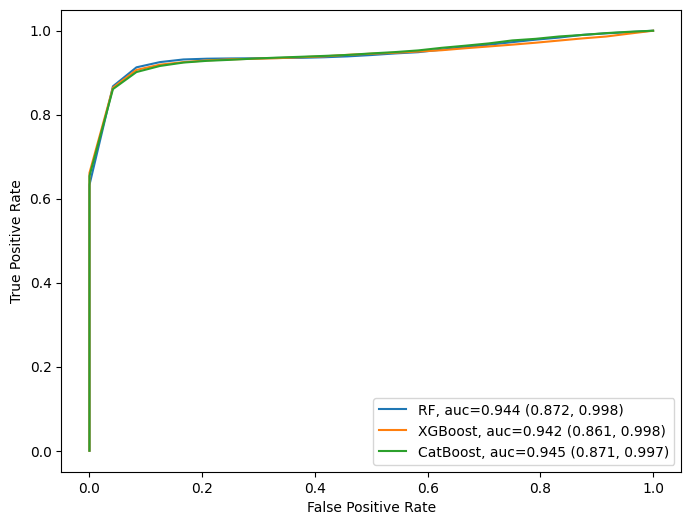

In [525]:
# 19. 繪製單平均 ROC 曲線 （圖上 AUC 的值之後要寫死）
"""
繪製三個模型的平均 ROC 曲線，風格與 #21 一致。

參數：
- fpr_list_rf, tpr_list_rf: Random Forest 的 FPR / TPR 結果 (多次 bootstrap)
- fpr_list_xgb, tpr_list_xgb: XGBoost 的 FPR / TPR 結果
- fpr_list_cat, tpr_list_cat: CatBoost 的 FPR / TPR 結果
"""

import matplotlib.pyplot as plt
import numpy as np

# 統一 FPR 閾值 (100 個點，使曲線更細緻)
mean_fpr = np.linspace(0, 1, 25)
mean_fpr = np.insert(mean_fpr, 0, 0)  # 確保 mean_fpr 從 0 開始

# 計算平均 ROC
def compute_mean_roc(fpr_list, tpr_list):
    tpr_interpolated = []
    for fpr, tpr in zip(fpr_list, tpr_list):
        if fpr[0] > 0:  # 如果 FPR 沒有從 0 開始
            fpr = np.insert(fpr, 0, 0)
            tpr = np.insert(tpr, 0, 0)  # 確保 TPR 也從 0 開始
        
        tpr_interp = np.interp(mean_fpr, fpr, tpr)  # 內插到統一 FPR
        tpr_interp[0] = 0  # 強制 TPR 在 FPR=0 時為 0
        tpr_interpolated.append(tpr_interp)
    return np.mean(tpr_interpolated, axis=0)

# 計算各模型的平均 ROC 曲線
mean_tpr_rf = compute_mean_roc(fpr_list_rf, tpr_list_rf)
mean_tpr_xgb = compute_mean_roc(fpr_list_xgb, tpr_list_xgb)
mean_tpr_cat = compute_mean_roc(fpr_list_cat, tpr_list_cat)

# 繪製 ROC 曲線
plt.figure(figsize=(8, 6))

# Random Forest
plt.plot(mean_fpr, mean_tpr_rf, label=f"RF, auc=0.944 (0.872, 0.998)")

# XGBoost
plt.plot(mean_fpr, mean_tpr_xgb, label=f"XGBoost, auc=0.942 (0.861, 0.998)")

# CatBoost
plt.plot(mean_fpr, mean_tpr_cat, label=f"CatBoost, auc=0.945 (0.871, 0.997)")

# 設定標籤與圖例
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.yticks(np.append(np.round(np.arange(0, 1.0, 0.2), 1), 1.0))  # 確保 1.0 也顯示在 Y 軸
plt.legend(loc="lower right")
plt.show()

In [ ]:
# 20. 主流程（CCH Holdout Validation Set 30% & MMH External Validation Set）

# 1. 直接用 70% CCH Training set 訓練
X_train_bootstrap, y_train_bootstrap = X_train, y_train  # 這次不做 Bootstrap

# 2. 使用 SMOTE 讓正負樣本平衡
smote = SMOTE(sampling_strategy={1: int(sum(y_train_bootstrap == 0) * 1)})
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_bootstrap, y_train_bootstrap)

# 3. Optuna 找最佳超參數（用 CCH 70% Training set）
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(lambda trial: objective_rf(trial, X_train_balanced, y_train_balanced), n_trials=20)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(lambda trial: objective_xgb(trial, X_train_balanced, y_train_balanced), n_trials=20)

study_catboost = optuna.create_study(direction="maximize")
study_catboost.optimize(lambda trial: objective_catboost(trial, X_train_balanced, y_train_balanced), n_trials=20)

# 4. 訓練模型（用 CCH 70% 訓練集）
best_rf = RandomForestClassifier(**study_rf.best_params)
best_xgb = XGBClassifier(**study_xgb.best_params)
best_catboost = CatBoostClassifier(**study_catboost.best_params, silent=True)

best_rf.fit(X_train_balanced, y_train_balanced)
best_xgb.fit(X_train_balanced, y_train_balanced)
best_catboost.fit(X_train_balanced, y_train_balanced)

# 5. 用 CCH Holdout Validation Set 測試
y_prob_rf_cch = best_rf.predict_proba(X_holdout)[:, 1]
y_prob_xgb_cch = best_xgb.predict_proba(X_holdout)[:, 1]
y_prob_cat_cch = best_catboost.predict_proba(X_holdout)[:, 1]

performance_rf_cch = calculate_metrics(y_holdout, y_prob_rf_cch)
performance_xgb_cch = calculate_metrics(y_holdout, y_prob_xgb_cch)
performance_catboost_cch = calculate_metrics(y_holdout, y_prob_cat_cch)

# 6. 用 MMH External Validation Set 測試
y_prob_rf_mmh = best_rf.predict_proba(MMH_features)[:, 1]
y_prob_xgb_mmh = best_xgb.predict_proba(MMH_features)[:, 1]
y_prob_cat_mmh = best_catboost.predict_proba(MMH_features)[:, 1]

performance_rf_mmh = calculate_metrics(MMH_labels, y_prob_rf_mmh)
performance_xgb_mmh = calculate_metrics(MMH_labels, y_prob_xgb_mmh)
performance_catboost_mmh = calculate_metrics(MMH_labels, y_prob_cat_mmh)

# 輸出最佳超參數組合
print("\n================= Best Hyperparameters (CCH 70% 訓練) =================")
print("\nRF Best Params:", study_rf.best_params)
print("XGBoost Best Params:", study_xgb.best_params)
print("CatBoost Best Params:", study_catboost.best_params)

# 定義格式化 Performance 指標的函數
def format_performance(performance):
    return pd.Series({key: f"{value:.3f}" for key, value in performance.items()})

# 輸出 70% 訓練 + 30% 測試的最佳超參數 & Performance 指標
print("\n================= Performance (70% 訓練, 30% 測試) =================")

print("\nRF Performance:")
print(format_performance(performance_rf_cch))

print("\nXGBoost Performance:")
print(format_performance(performance_xgb_cch))

print("\nCatBoost Performance:")
print(format_performance(performance_catboost_cch))

# 輸出 MMH External Validation Performance 指標
print("\n================= Performance (MMH External Validation) =================")

print("\nRF Performance:")
print(format_performance(performance_rf_mmh))

print("\nXGBoost Performance:")
print(format_performance(performance_xgb_mmh))

print("\nCatBoost Performance:")
print(format_performance(performance_catboost_mmh))


================= Best Hyperparameters (CCH 70% 訓練) =================

RF Best Params: {'n_estimators': 497, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1}
XGBoost Best Params: {'n_estimators': 479, 'max_depth': 11, 'learning_rate': 0.08257279874749135, 'subsample': 0.5062045096091431, 'colsample_bytree': 0.758809681687877, 'gamma': 0.3608506993292204, 'lambda': 0.001863229974506899}
CatBoost Best Params: {'iterations': 491, 'depth': 4, 'learning_rate': 0.07676762939599932, 'l2_leaf_reg': 0.005714019309759579, 'bagging_temperature': 0.025579526366002026}

================= Performance (70% 訓練, 30% 測試) =================

RF Performance:
F1             0.766
AUC            0.933
Sensitivity    0.750
Specificity    0.966
Precision      0.783
Accuracy       0.935
dtype: object

XGBoost Performance:
F1             0.735
AUC            0.917
Sensitivity    0.750
Specificity    0.952
Precision      0.720
Accuracy       0.923
dtype: object

CatBoost Performance:
F1           

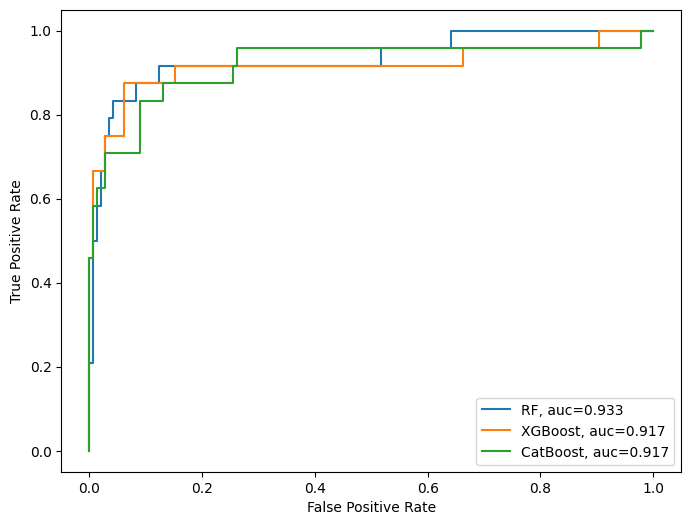

In [493]:
# 21. 繪製 CCH Holdout Validation Set 的 ROC 曲線
plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_holdout, y_prob_rf_cch)
plt.plot(fpr_rf, tpr_rf, label=f"RF, auc={performance_rf_cch['AUC']:.3f}")

fpr_xgb, tpr_xgb, _ = roc_curve(y_holdout, y_prob_xgb_cch)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost, auc={performance_xgb_cch['AUC']:.3f}")

fpr_cat, tpr_cat, _ = roc_curve(y_holdout, y_prob_cat_cch)
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost, auc={performance_catboost_cch['AUC']:.3f}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

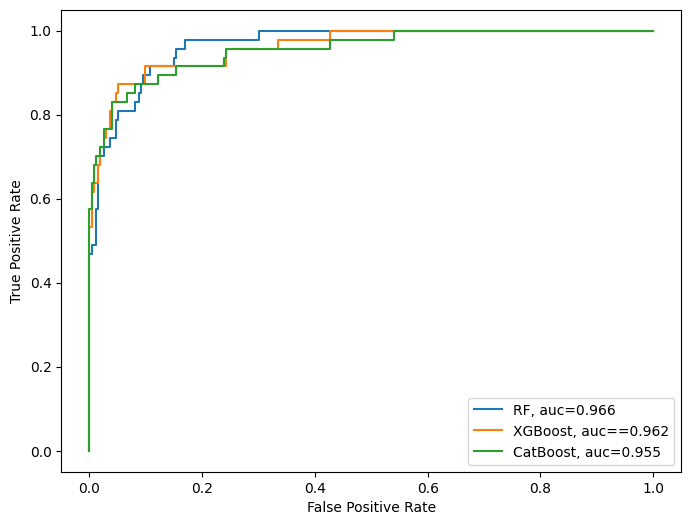

In [494]:
# 22. 繪製 MMH External Validation Set 的 ROC 曲線
plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(MMH_labels, y_prob_rf_mmh)
plt.plot(fpr_rf, tpr_rf, label=f"RF, auc={performance_rf_mmh['AUC']:.3f}")

fpr_xgb, tpr_xgb, _ = roc_curve(MMH_labels, y_prob_xgb_mmh)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost, auc=={performance_xgb_mmh['AUC']:.3f}")

fpr_cat, tpr_cat, _ = roc_curve(MMH_labels, y_prob_cat_mmh)
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost, auc={performance_catboost_mmh['AUC']:.3f}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [656]:
# 23. 匯入 SHAP 進行特徵重要性分析
'''
可以看到 哪些特徵對模型預測結果的影響最大。
'''
import shap

In [650]:
# 24. 建立 SHAP 解釋器（Random Forest 模型）
'''
shap.Explainer(best_rf) 創建一個 SHAP 模型解釋器，用來分析 隨機森林（RF）模型 的預測邏輯。
接下來的步驟會用這個解釋器來分析 SHAP 值。
'''
explainer = shap.Explainer(best_rf)

In [651]:
# 25. 計算 CCH 70% 訓練數據的 SHAP 值
'''
計算 CCH 70% 訓練數據的 SHAP 值。
shap_values 代表每個特徵對模型預測結果的影響力。
'''
shap_values = explainer.shap_values(X_train)

In [652]:
# 26. 重新命名特徵名稱
'''
將特徵名稱改成更直觀的名稱，方便 SHAP 圖表顯示。
'''
X_train_feature_importance = X_train.copy()
X_train_feature_importance.columns = ['Age', 'Sex', 'CCI', 'Cancer site', 'Stage', 'Chemotherapy', 'Smoking', 'SMI', 'CE Dmean',
                                      'Cricopharyngeus Dmean', 'EIM Dmean', 'Glottic larynx Dmean', 'IPCM Dmean', 'MPCM Dmean',
                                      'SPCM Dmean', 'Supraglottic larynx Dmean']

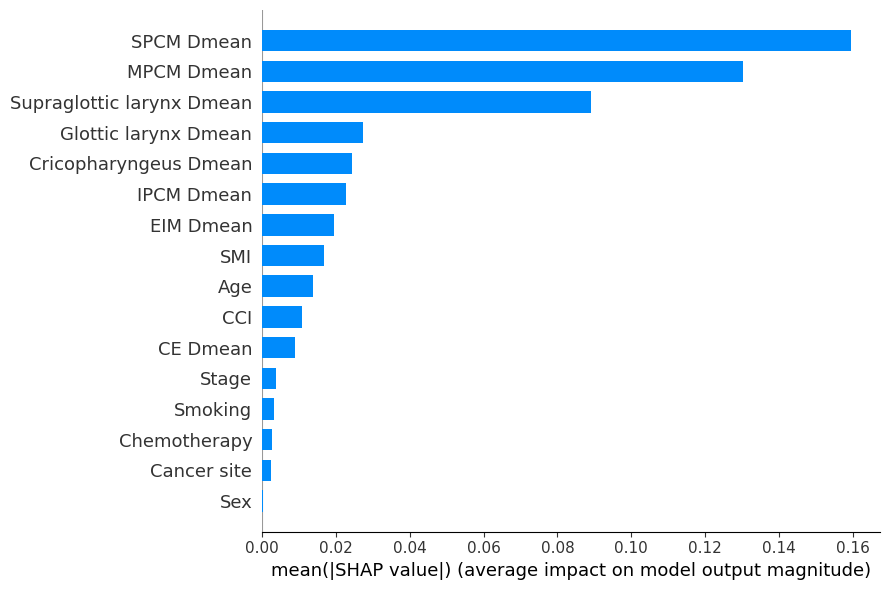

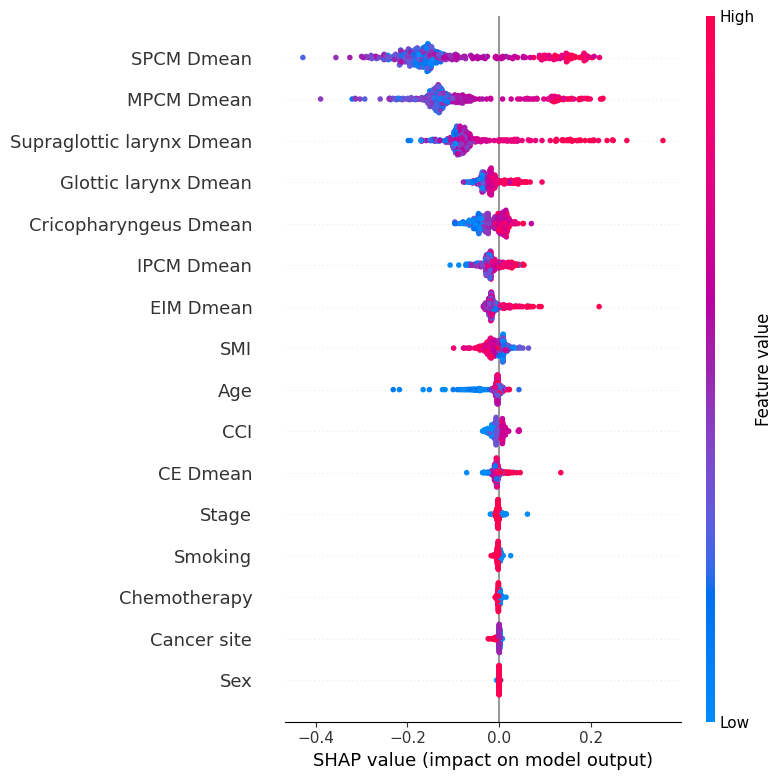

In [ ]:
# 27. 繪製 CCH 70% 訓練數據的 SHAP 特徵重要性
'''
繪製 CCH 70% 訓練數據的 SHAP 特徵重要性。
shap_values 代表每個特徵對模型預測結果的影響力。
'''
shap_values_selected = shap_values[:, :, 1]  # 選擇類別 1 的 SHAP 值
shap.summary_plot(shap_values_selected, X_train_feature_importance, plot_type='bar', plot_size=(9,6))
shap.summary_plot(shap_values_selected, X_train_feature_importance)

In [669]:
# 28. 計算 CCH 30% 驗證數據的 SHAP 值
'''
計算 CCH 30% 驗證數據的 SHAP 值。
shap_values_holdout 代表每個特徵對模型預測結果的影響力。
'''
shap_values_holdout = explainer.shap_values(X_holdout)

In [670]:
# 29. 重新命名特徵名稱
'''
將特徵名稱改成更直觀的名稱，方便 SHAP 圖表顯示。
'''
X_holdout_feature_importance = X_holdout.copy()
X_holdout_feature_importance.columns = ['Age', 'Sex', 'CCI', 'Cancer site', 'Stage', 'Chemotherapy', 'Smoking', 'SMI', 'CE Dmean',
                                      'Cricopharyngeus Dmean', 'EIM Dmean', 'Glottic larynx Dmean', 'IPCM Dmean', 'MPCM Dmean',
                                      'SPCM Dmean', 'Supraglottic larynx Dmean']

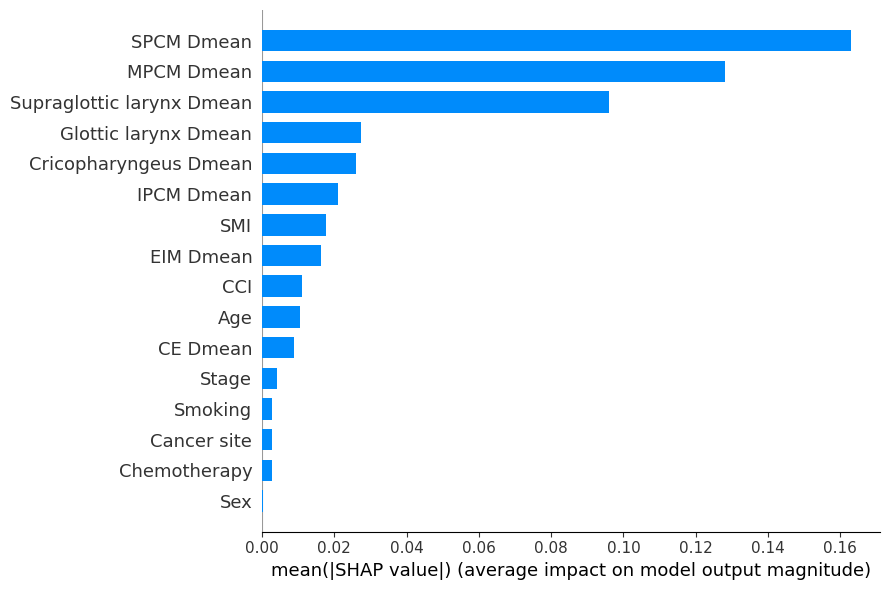

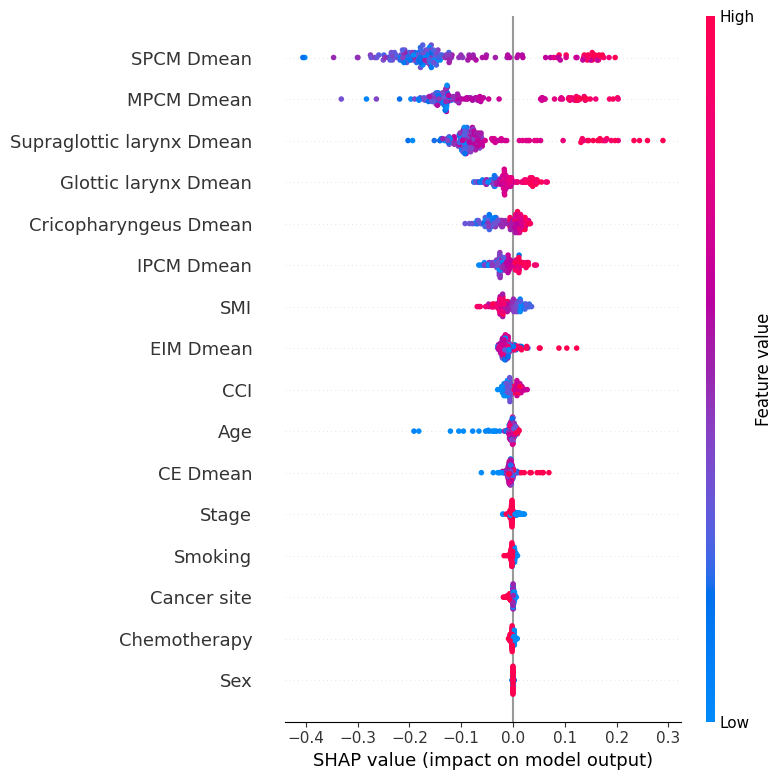

In [676]:
# 30. 繪製 CCH 30% 訓練數據的 SHAP 特徵重要性
'''
繪製 CCH 30% 訓練數據的 SHAP 特徵重要性。
shap_values 代表每個特徵對模型預測結果的影響力。
'''
shap_values_holdout_selected = shap_values_holdout[:, :, 1]  # 選擇類別 1 的 SHAP 值
shap.summary_plot(shap_values_holdout_selected, X_holdout_feature_importance, plot_type='bar', plot_size=(9,6))
shap.summary_plot(shap_values_holdout_selected, X_holdout_feature_importance)

In [672]:
# 31. 計算 MMH External Validation Set 驗證數據的 SHAP 值
'''
計算 MMH External Validation Set 驗證數據的 SHAP 值。
shap_values_holdout 代表每個特徵對模型預測結果的影響力。
'''
shap_values_MMH = explainer.shap_values(MMH_features)

In [673]:
# 32. 重新命名特徵名稱
'''
將特徵名稱改成更直觀的名稱，方便 SHAP 圖表顯示。
'''
MMH_features_feature_importance = MMH_features.copy()
MMH_features_feature_importance.columns = ['Age', 'Sex', 'CCI', 'Cancer site', 'Stage', 'Chemotherapy', 'Smoking', 'SMI', 'CE Dmean',
                                      'Cricopharyngeus Dmean', 'EIM Dmean', 'Glottic larynx Dmean', 'IPCM Dmean', 'MPCM Dmean',
                                      'SPCM Dmean', 'Supraglottic larynx Dmean']

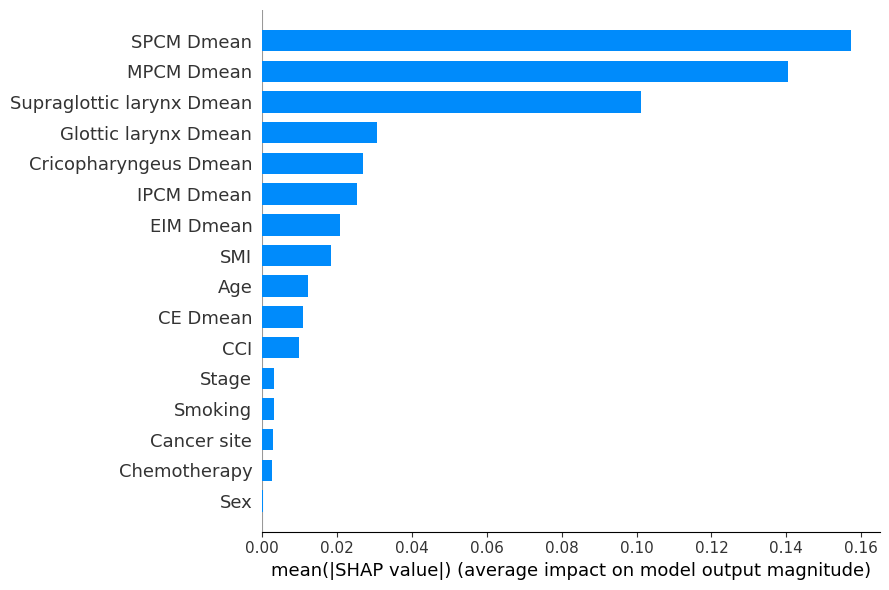

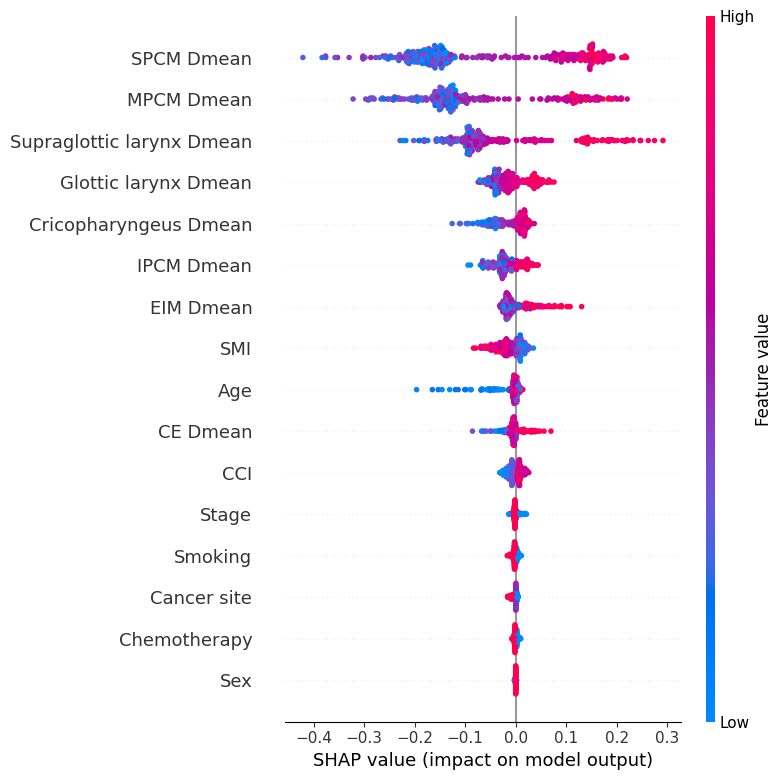

In [677]:
# 33. 繪製 CCH 30% 訓練數據的 SHAP 特徵重要性
'''
繪製 MMH External Validation Set 訓練數據的 SHAP 特徵重要性。
shap_values 代表每個特徵對模型預測結果的影響力。
'''
shap_values_MMH_selected = shap_values_MMH[:, :, 1]  # 選擇類別 1 的 SHAP 值
shap.summary_plot(shap_values_MMH_selected, MMH_features_feature_importance, plot_type='bar', plot_size=(9,6))
shap.summary_plot(shap_values_MMH_selected, MMH_features_feature_importance)

In [711]:
# 34. 計算 SHAP 值（針對三個數據集）
'''
計算 CCH 70% 訓練集、CCH 30% 驗證集、MMH 外部驗證集的 SHAP 值
'''
features_train = X_train  # CCH 70%
features_valid = X_holdout  # CCH 30%
features_external = MMH_features  # MMH 外部驗證集

# 計算 SHAP 值
shap_values_train = explainer.shap_values(features_train)
shap_values_valid = explainer.shap_values(features_valid)
shap_values_external = explainer.shap_values(features_external)

# 只取類別 1 的 SHAP 值
shap_values_train = shap_values_train[:, :, 1]
shap_values_valid = shap_values_valid[:, :, 1]
shap_values_external = shap_values_external[:, :, 1]


<Figure size 600x500 with 0 Axes>

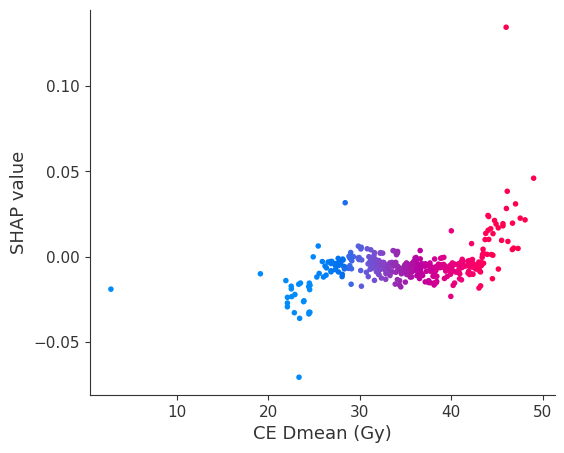

<Figure size 600x500 with 0 Axes>

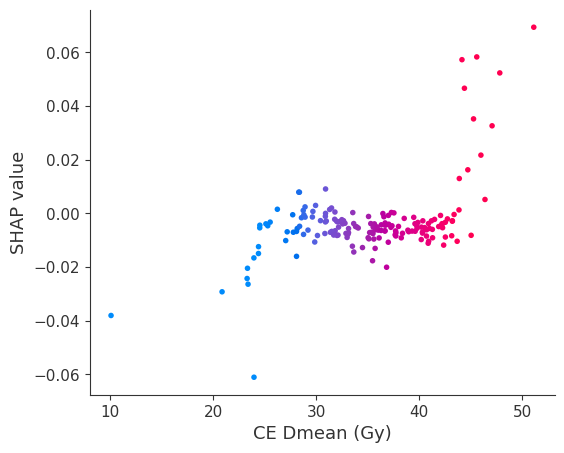

<Figure size 600x500 with 0 Axes>

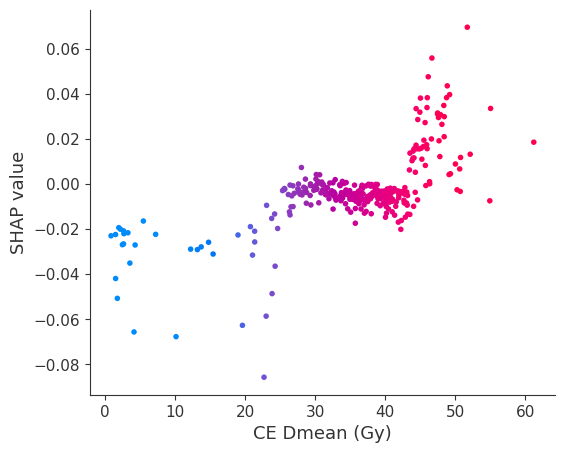

In [712]:
# 35-1. SHAP 依賴關係圖（CCH 70% 訓練集 - CE Dmean）
'''
針對 CCH 70% 訓練集，繪製 CE Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('CE', shap_values_train, features_train, interaction_index='CE', show=False)
plt.xlabel('CE Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 35-2. SHAP 依賴關係圖（CCH 30% 驗證集 - CE Dmean）
'''
針對 CCH 30% 驗證集，繪製 CE Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('CE', shap_values_valid, features_valid, interaction_index='CE', show=False)
plt.xlabel('CE Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 35-3. SHAP 依賴關係圖（MMH 外部驗證集 - CE Dmean）
'''
針對 MMH 外部驗證集，繪製 CE Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('CE', shap_values_external, features_external, interaction_index='CE', show=False)
plt.xlabel('CE Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

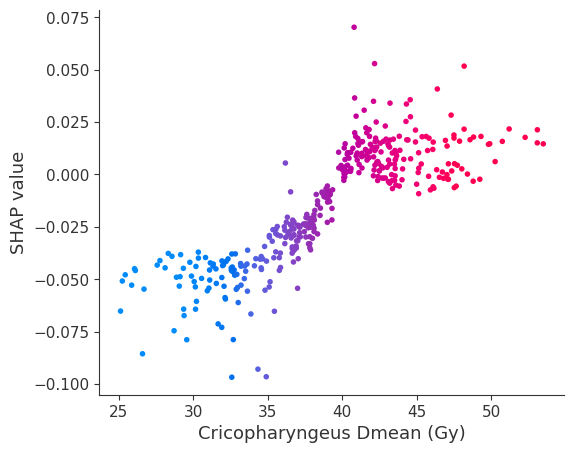

<Figure size 600x500 with 0 Axes>

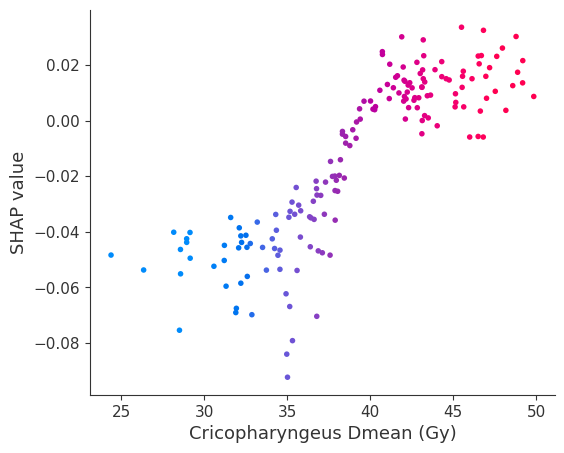

<Figure size 600x500 with 0 Axes>

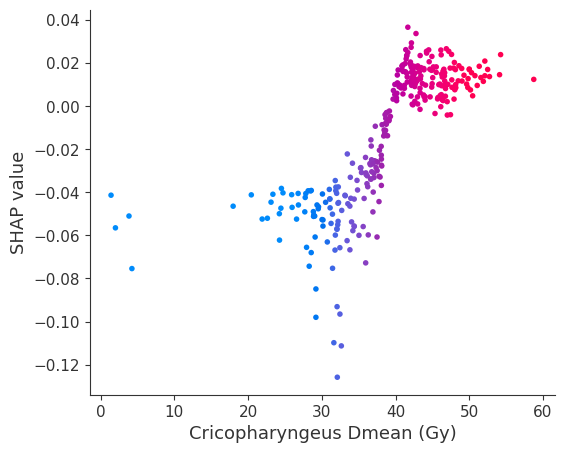

In [713]:
# 36-1. SHAP 依賴關係圖（CCH 70% 訓練集 - Cricopharyngeus Dmean）
'''
針對 CCH 70% 訓練集，繪製 Cricopharyngeus Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Cricopharyngeus', shap_values_train, features_train, interaction_index='Cricopharyngeus', show=False)
plt.xlabel('Cricopharyngeus Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 36-2. SHAP 依賴關係圖（CCH 30% 驗證集 - Cricopharyngeus Dmean）
'''
針對 CCH 30% 驗證集，繪製 Cricopharyngeus Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Cricopharyngeus', shap_values_valid, features_valid, interaction_index='Cricopharyngeus', show=False)
plt.xlabel('Cricopharyngeus Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 36-3. SHAP 依賴關係圖（MMH 外部驗證集 - Cricopharyngeus Dmean）
'''
針對 MMH 外部驗證集，繪製 Cricopharyngeus Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Cricopharyngeus', shap_values_external, features_external, interaction_index='Cricopharyngeus', show=False)
plt.xlabel('Cricopharyngeus Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

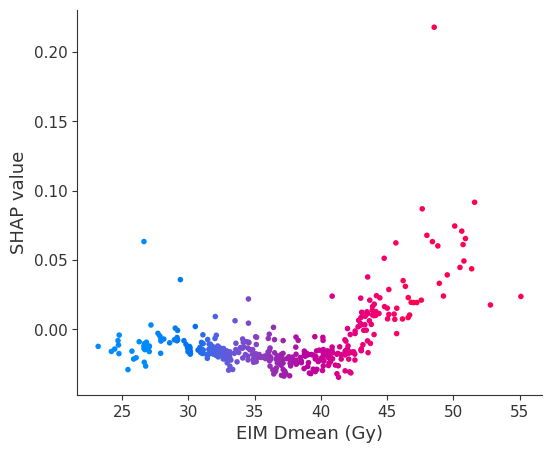

<Figure size 600x500 with 0 Axes>

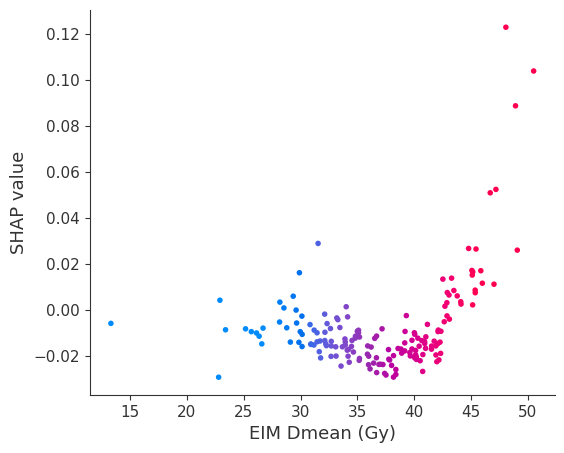

<Figure size 600x500 with 0 Axes>

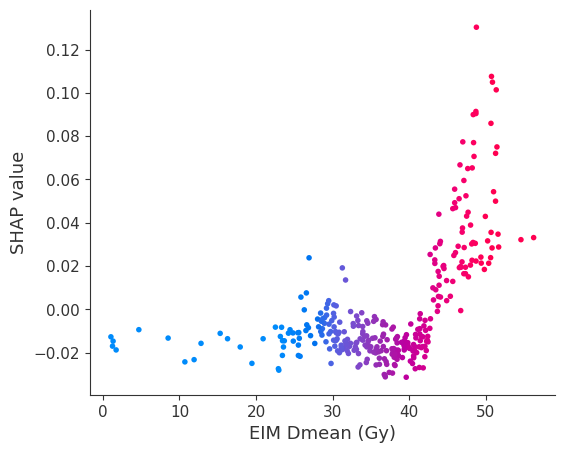

In [714]:
# 37-1. SHAP 依賴關係圖（CCH 70% 訓練集 - EIM Dmean）
'''
針對 CCH 70% 訓練集，繪製 EIM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('EIM', shap_values_train, features_train, interaction_index='EIM', show=False)
plt.xlabel('EIM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 37-2. SHAP 依賴關係圖（CCH 30% 驗證集 - EIM Dmean）
'''
針對 CCH 30% 驗證集，繪製 EIM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('EIM', shap_values_valid, features_valid, interaction_index='EIM', show=False)
plt.xlabel('EIM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 37-3. SHAP 依賴關係圖（MMH 外部驗證集 - EIM Dmean）
'''
針對 MMH 外部驗證集，繪製 EIM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('EIM', shap_values_external, features_external, interaction_index='EIM', show=False)
plt.xlabel('EIM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

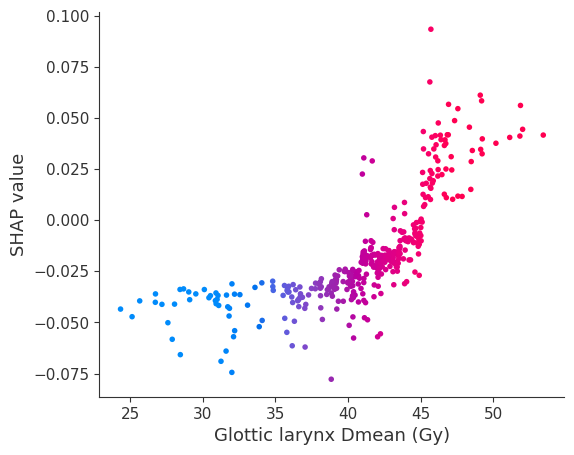

<Figure size 600x500 with 0 Axes>

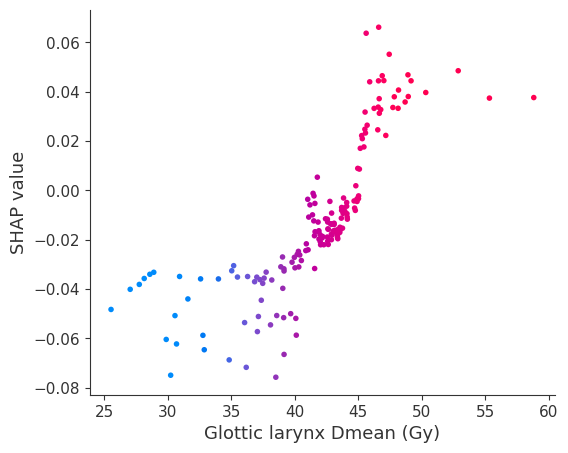

<Figure size 600x500 with 0 Axes>

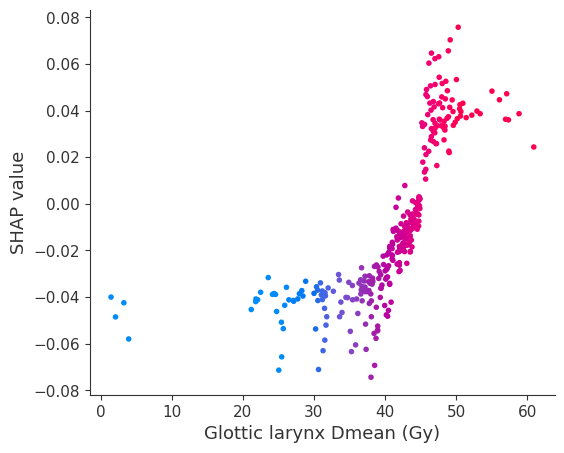

In [715]:
# 38-1. SHAP 依賴關係圖（CCH 70% 訓練集 - Glottic larynx Dmean）
'''
針對 CCH 70% 訓練集，繪製 Glottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('GL', shap_values_train, features_train, interaction_index='GL', show=False)
plt.xlabel('Glottic larynx (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 38-2. SHAP 依賴關係圖（CCH 30% 驗證集 - Glottic larynx Dmean）
'''
針對 CCH 30% 驗證集，繪製 Glottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('GL', shap_values_valid, features_valid, interaction_index='GL', show=False)
plt.xlabel('Glottic larynx (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 38-3. SHAP 依賴關係圖（MMH 外部驗證集 - Glottic larynx Dmean）
'''
針對 MMH 外部驗證集，繪製 Glottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('GL', shap_values_external, features_external, interaction_index='GL', show=False)
plt.xlabel('Glottic larynx (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

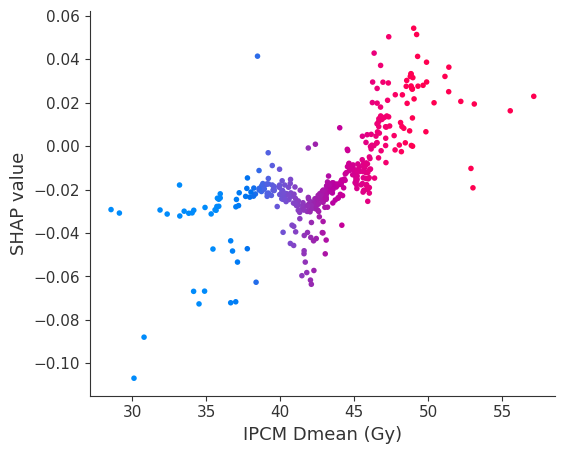

<Figure size 600x500 with 0 Axes>

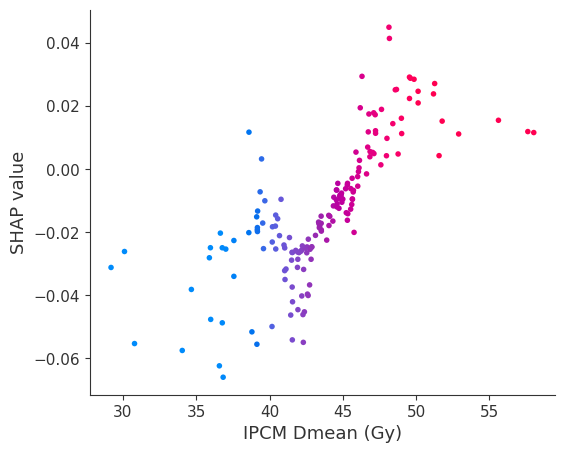

<Figure size 600x500 with 0 Axes>

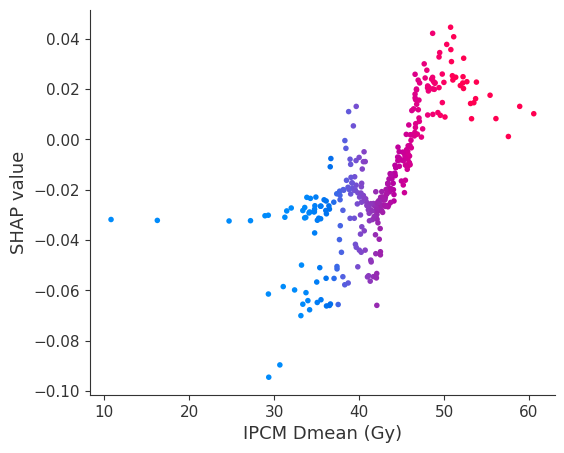

In [718]:
# 39-1. SHAP 依賴關係圖（CCH 70% 訓練集 - IPCM Dmean）
'''
針對 CCH 70% 訓練集，繪製 IPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Inferior_PCM', shap_values_train, features_train, interaction_index='Inferior_PCM', show=False)
plt.xlabel('IPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 39-2. SHAP 依賴關係圖（CCH 30% 驗證集 - IPCM Dmean）
'''
針對 CCH 30% 驗證集，繪製 IPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Inferior_PCM', shap_values_valid, features_valid, interaction_index='Inferior_PCM', show=False)
plt.xlabel('IPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 39-3. SHAP 依賴關係圖（MMH 外部驗證集 - IPCM Dmean）
'''
針對 MMH 外部驗證集，繪製 IPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Inferior_PCM', shap_values_external, features_external, interaction_index='Inferior_PCM', show=False)
plt.xlabel('IPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

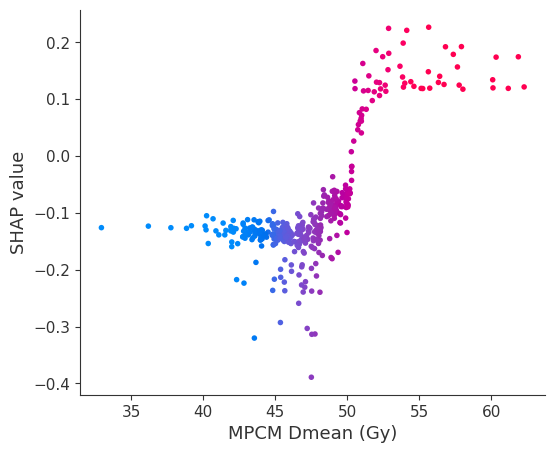

<Figure size 600x500 with 0 Axes>

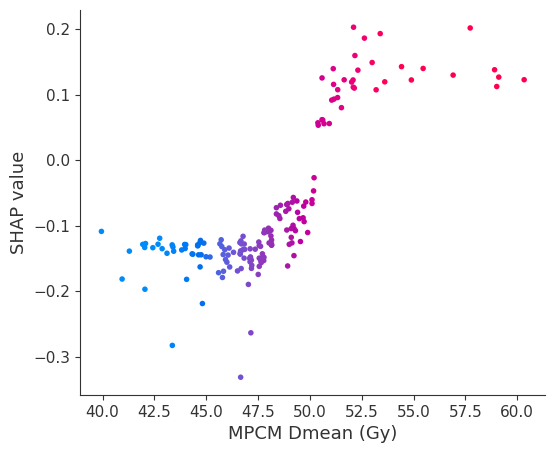

<Figure size 600x500 with 0 Axes>

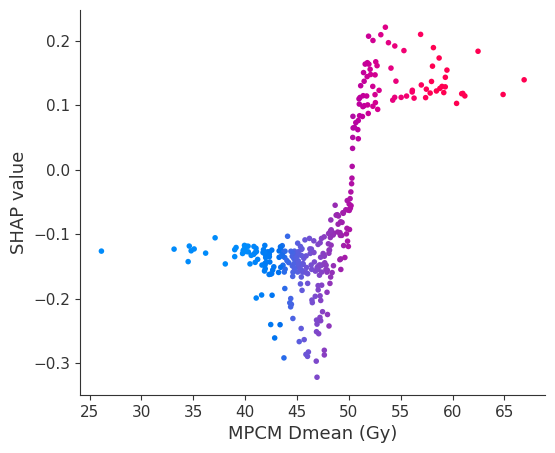

In [719]:
# 40-1. SHAP 依賴關係圖（CCH 70% 訓練集 - MPCM Dmean）
'''
針對 CCH 70% 訓練集，繪製 MPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Middle_PCM', shap_values_train, features_train, interaction_index='Middle_PCM', show=False)
plt.xlabel('MPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 40-2. SHAP 依賴關係圖（CCH 30% 驗證集 - MPCM Dmean）
'''
針對 CCH 30% 驗證集，繪製 MPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Middle_PCM', shap_values_valid, features_valid, interaction_index='Middle_PCM', show=False)
plt.xlabel('MPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 40-3. SHAP 依賴關係圖（MMH 外部驗證集 - MPCM Dmean）
'''
針對 MMH 外部驗證集，繪製 MPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Middle_PCM', shap_values_external, features_external, interaction_index='Middle_PCM', show=False)
plt.xlabel('MPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

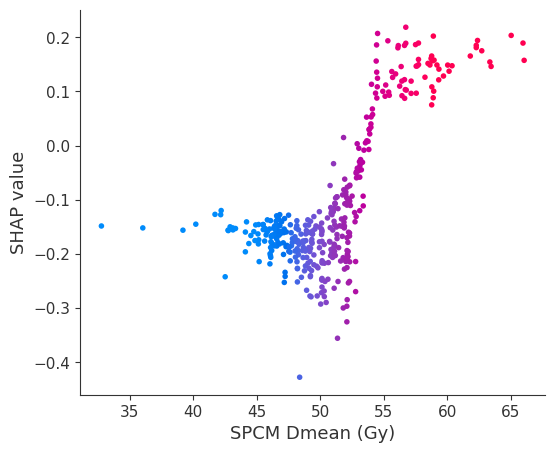

<Figure size 600x500 with 0 Axes>

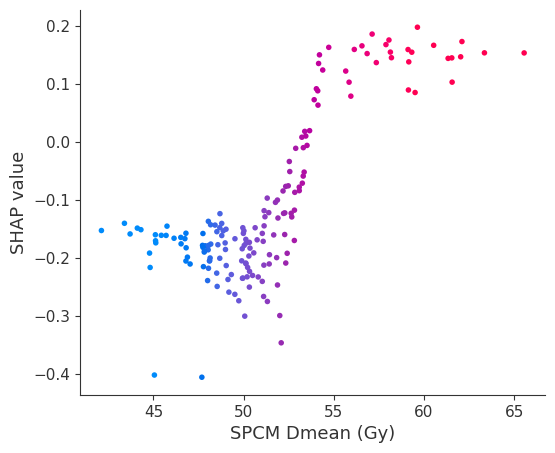

<Figure size 600x500 with 0 Axes>

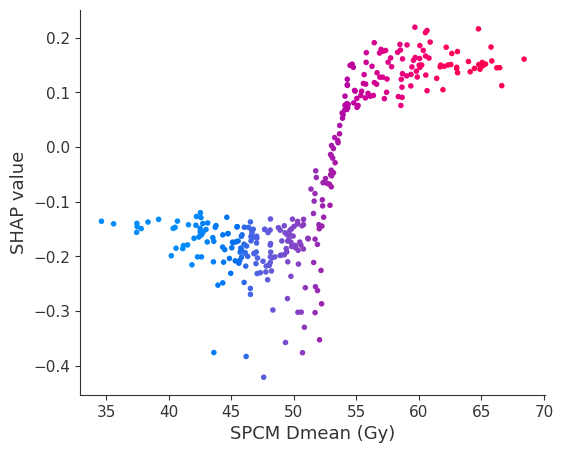

In [720]:
# 41-1. SHAP 依賴關係圖（CCH 70% 訓練集 - SPCM Dmean）
'''
針對 CCH 70% 訓練集，繪製 SPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Superior_PCM', shap_values_train, features_train, interaction_index='Superior_PCM', show=False)
plt.xlabel('SPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 41-2. SHAP 依賴關係圖（CCH 30% 驗證集 - SPCM Dmean）
'''
針對 CCH 30% 驗證集，繪製 SPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Superior_PCM', shap_values_valid, features_valid, interaction_index='Superior_PCM', show=False)
plt.xlabel('SPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 41-3. SHAP 依賴關係圖（MMH 外部驗證集 - SPCM Dmean）
'''
針對 MMH 外部驗證集，繪製 SPCM Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('Superior_PCM', shap_values_external, features_external, interaction_index='Superior_PCM', show=False)
plt.xlabel('SPCM Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

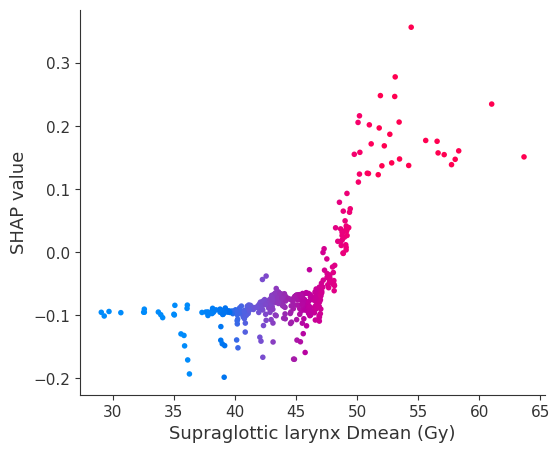

<Figure size 600x500 with 0 Axes>

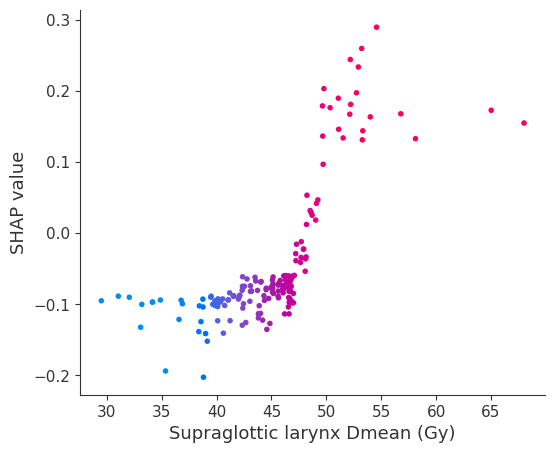

<Figure size 600x500 with 0 Axes>

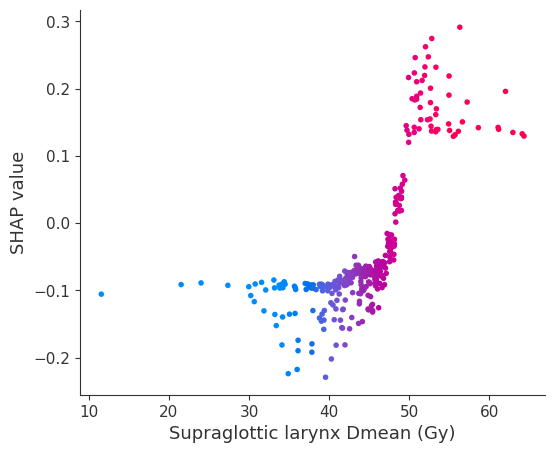

In [721]:
# 42-1. SHAP 依賴關係圖（CCH 70% 訓練集 - Supraglottic larynx Dmean）
'''
針對 CCH 70% 訓練集，繪製 Supraglottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SGL', shap_values_train, features_train, interaction_index='SGL', show=False)
plt.xlabel('Supraglottic larynx Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

# 42-2. SHAP 依賴關係圖（CCH 30% 驗證集 - Supraglottic larynx Dmean）
'''
針對 CCH 30% 驗證集，繪製 Supraglottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SGL', shap_values_valid, features_valid, interaction_index='SGL', show=False)
plt.xlabel('Supraglottic larynx Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()


# 42-3. SHAP 依賴關係圖（MMH 外部驗證集 - Supraglottic larynx Dmean）
'''
針對 MMH 外部驗證集，繪製 Supraglottic larynx Dmean 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SGL', shap_values_external, features_external, interaction_index='SGL', show=False)
plt.xlabel('Supraglottic larynx Dmean (Gy)')
plt.ylabel('SHAP value')
plt.show()

<Figure size 600x500 with 0 Axes>

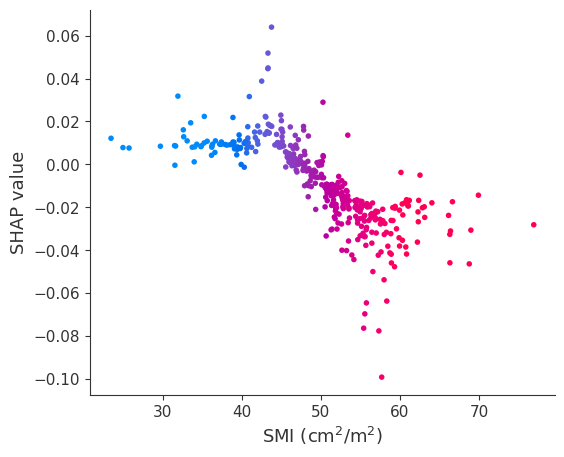

<Figure size 600x500 with 0 Axes>

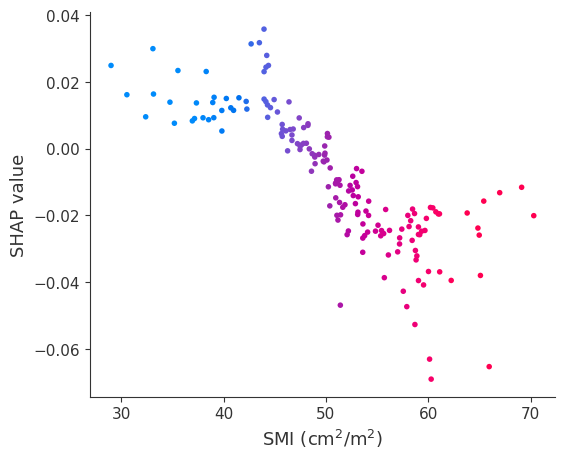

<Figure size 600x500 with 0 Axes>

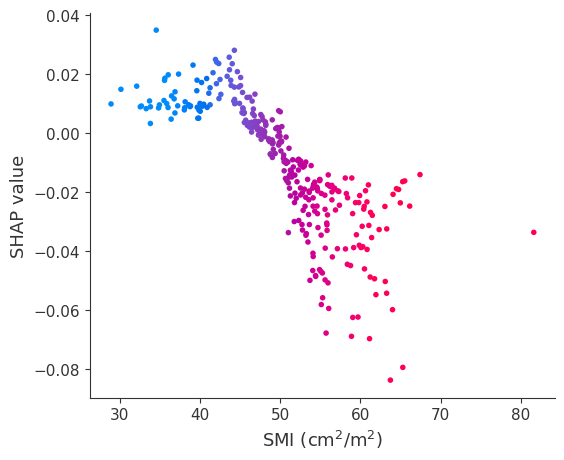

In [722]:
# 43-1. SHAP 依賴關係圖（CCH 70% 訓練集 - SMI (cm2/m2)）
'''
針對 CCH 70% 訓練集，繪製 SMI (cm2/m2) 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SMI', shap_values_train, features_train, interaction_index='SMI', show=False)
plt.xlabel(r'SMI (cm$^2$/m$^2$)')
plt.ylabel('SHAP value')
plt.show()

# 43-2. SHAP 依賴關係圖（CCH 30% 驗證集 - SMI (cm2/m2)）
'''
針對 CCH 30% 驗證集，繪製 SMI (cm2/m2) 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SMI', shap_values_valid, features_valid, interaction_index='SMI', show=False)
plt.xlabel(r'SMI (cm$^2$/m$^2$)')
plt.ylabel('SHAP value')
plt.show()


# 43-3. SHAP 依賴關係圖（MMH 外部驗證集 - SMI (cm2/m2)）
'''
針對 MMH 外部驗證集，繪製 SMI (cm2/m2) 的 SHAP 依賴關係圖。
'''
plt.figure(figsize=(6, 5))
shap.dependence_plot('SMI', shap_values_external, features_external, interaction_index='SMI', show=False)
plt.xlabel(r'SMI (cm$^2$/m$^2$)')
plt.ylabel('SHAP value')
plt.show()

Text(0, 0.5, 'SHAP value')

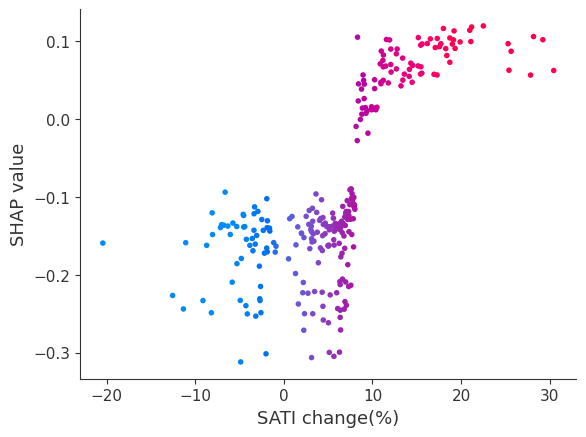

In [74]:
# 55. SHAP 依賴關係圖：rSATI_change（皮下脂肪指數變化率）
_, ax = plt.subplots()

shap.dependence_plot('rSATI_change', shap_values, features, interaction_index='rSATI_change', ax = ax, show= False)
ax.set_xlabel('SATI change(%)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

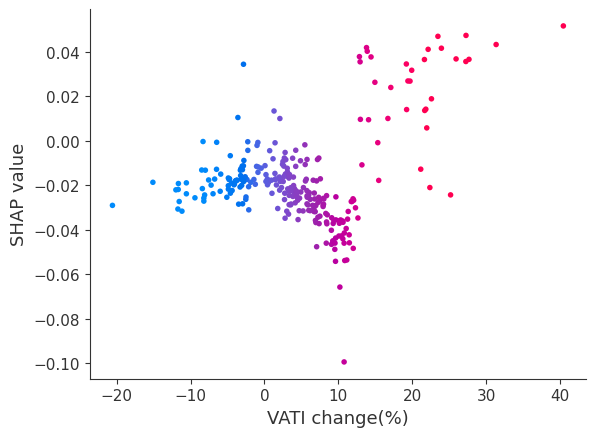

In [75]:
# 56. SHAP 依賴關係圖：rVATI_change（內臟脂肪指數變化率）
_, ax = plt.subplots()

shap.dependence_plot('rVATI_change', shap_values, features, interaction_index='rVATI_change', ax = ax, show= False)
ax.set_xlabel('VATI change(%)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

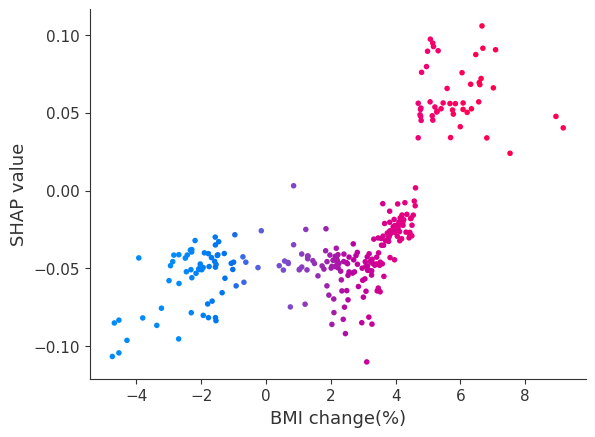

In [76]:
# 57. SHAP 依賴關係圖：rBMI_change（BMI 變化率）
_, ax = plt.subplots()

shap.dependence_plot('rBMI_change', shap_values, features, interaction_index='rBMI_change', ax = ax, show= False)
ax.set_xlabel('BMI change(%)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

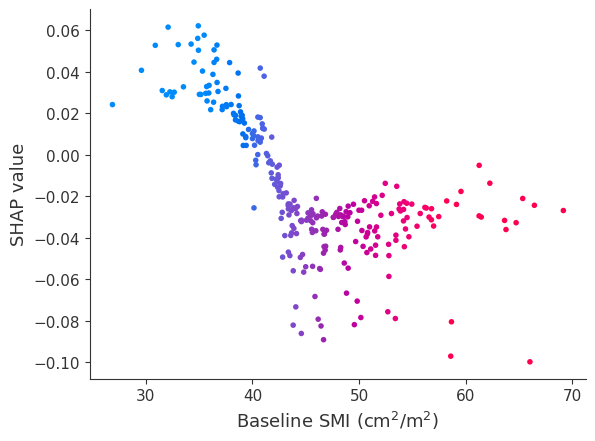

In [77]:
# 58. SHAP 依賴關係圖：SMI_1（基礎 SMI）
_, ax = plt.subplots()

shap.dependence_plot('SMI_1', shap_values, features, interaction_index='SMI_1', ax = ax, show= False)
ax.set_xlabel('Baseline SMI (cm$^2$/m$^2$)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

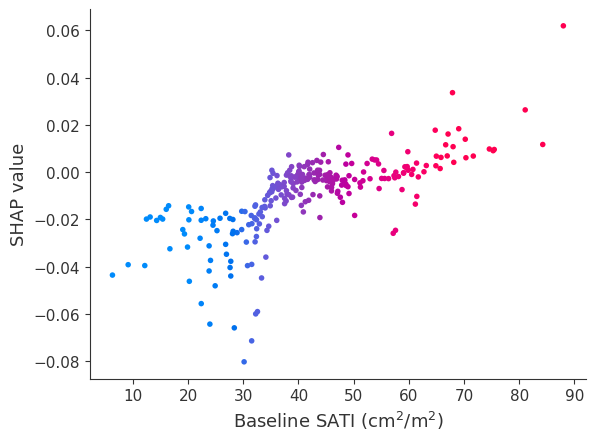

In [78]:
# 59. SHAP 依賴關係圖：SATI_1（基礎 SATI）
_, ax = plt.subplots()

shap.dependence_plot('SATI_1', shap_values, features, interaction_index='SATI_1', ax = ax, show= False)
ax.set_xlabel('Baseline SATI (cm$^2$/m$^2$)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

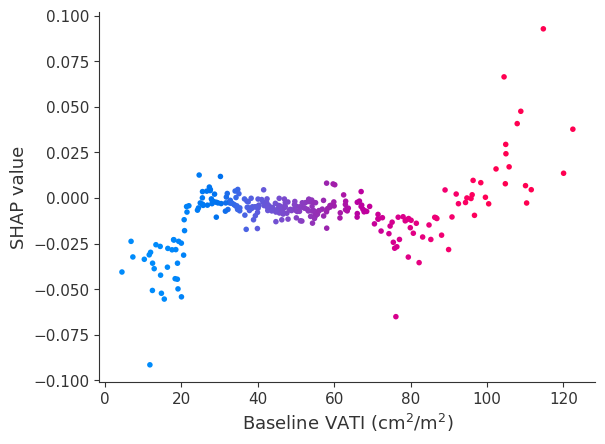

In [79]:
# 60. SHAP 依賴關係圖：VATI_1（基礎 VATI）
_, ax = plt.subplots()

shap.dependence_plot('VATI_1', shap_values, features, interaction_index='VATI_1', ax = ax, show= False)
ax.set_xlabel('Baseline VATI (cm$^2$/m$^2$)')
ax.set_ylabel('SHAP value')


Text(0, 0.5, 'SHAP value')

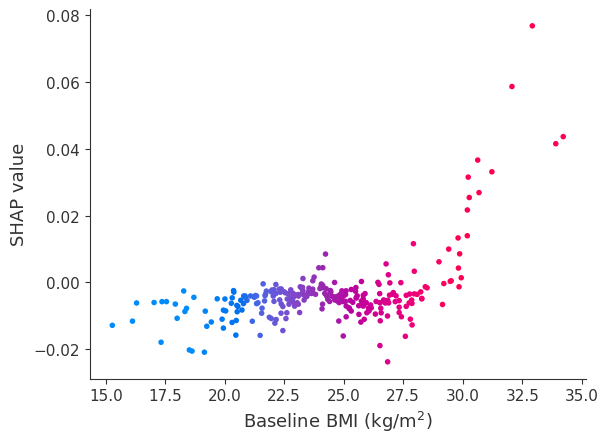

In [80]:
# 61. SHAP 依賴關係圖：BMI_1（基礎 BMI）
_, ax = plt.subplots()

shap.dependence_plot('BMI_1', shap_values, features, interaction_index='BMI_1', ax = ax, show= False)
ax.set_xlabel('Baseline BMI (kg/m$^2$)')
ax.set_ylabel('SHAP value')
